**`Cell 1: GPU, Drive and data`**

**1.** Check GPU availability

**2.** **Why do we need it?**

Solar Guard may use a deep learning model to analyze solar panel images and detect contamination, such as dust or bird droppings. A GPU can make training and image processing much faster.


In [1]:
import torch
assert torch.cuda.is_available(), "GPU is off: Runtime > Change runtime type > T4 GPU"
print(torch.__version__, "| GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount("/content/drive")

!mkdir -p /content/data
!cp -r "/content/drive/MyDrive/solarGuard" /content/data/

2.11.0+cu130 | GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **`Cell 2: create the package folder**

In [2]:
!mkdir -p /content/drive/MyDrive/solarGuard/code/solarguard
!touch /content/drive/MyDrive/solarGuard/code/solarguard/__init__.py

# **Cell 3:** `config.py`

**Central Configuration (`config.py`):** This cell defines the central configuration of our Solar Guard project, keeping all important settings in one place for easy management and consistency. It defines two classification categories, Clean and Dirty, and maps them to numerical labels (0 and 1) for model training. It specifies ImageNet normalization values for preprocessing images before feeding them into the pretrained MobileNetV2 model. It also defines the dataset folder structure, image storage paths, random seed for reproducibility, image size (224 × 224), batch size (32), number of data-loading workers, and the proportions reserved for training, validation, and testing. The `Config` dataclass stores these settings, while `frozen=True` prevents accidental modification after initialization. Finally, the `__post_init__()` method validates important settings and raises errors if invalid values are provided. Overall, this cell acts as the project's central control panel, helping other modules load the correct data, apply consistent preprocessing, and configure model training and evaluation. It defines the settings but does not itself load images or train the model.


In [3]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/config.py
"""Central configuration for SolarGuard. Change a value here, nowhere else."""
from dataclasses import dataclass
from pathlib import Path

CLASS_NAMES = ("Clean", "Dirty")
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# Statistics of the ImageNet dataset that MobileNetV2 was pretrained on.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Folder (relative to image_root) -> (label, split the dataset author used).
FOLDER_LABELS = {
    "Training data/Clean": ("Clean", "train"),
    "Training data/Dirty": ("Dirty", "train"),
    "Testing data/Clean": ("Clean", "test"),
    "Testing data/Dirty": ("Dirty", "test"),
}


@dataclass(frozen=True)
class Config:
    """Immutable settings: frozen=True means nothing can change them mid-run."""

    image_root: Path = Path(
        "/content/data/solarGuard/New folder/Resized unprocessed images"
    )
    split_dir: Path = Path("/content/drive/MyDrive/solarGuard/splits")
    seed: int = 42
    session_gap_seconds: int = 300
    test_fraction: float = 0.20
    val_fraction: float = 0.15
    img_size: int = 224
    batch_size: int = 32
    num_workers: int = 2

    def __post_init__(self) -> None:
        if not 0 < self.test_fraction < 1 or not 0 < self.val_fraction < 1:
            raise ValueError("test_fraction and val_fraction must be between 0 and 1")
        if self.test_fraction + self.val_fraction >= 1:
            raise ValueError("test_fraction + val_fraction must leave room for training")
        if self.session_gap_seconds <= 0 or self.batch_size <= 0 or self.img_size <= 0:
            raise ValueError("session_gap_seconds, batch_size and img_size must be positive")

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/config.py


**Cell 4 — Data Preparation (`dataprep.py`):** This cell prepares the Solar Guard image dataset for reliable model training and evaluation by creating separate training, validation, and testing sets while preventing data leakage. The `parse_timestamp()` function extracts image capture timestamps from filenames, ensuring that images without valid timestamps are flagged instead of silently ignored. The `build_image_table()` function creates a structured table containing each image's path, filename, class label, original dataset split, and timestamp. The `assign_sessions()` function groups photos taken within five minutes of one another into the same session because they may show the same solar panel under similar conditions. The `split_by_session()` function uses `GroupShuffleSplit` to ensure that images from the same session cannot appear across different dataset splits, reducing the risk of inflated accuracy caused by near-duplicate images. The `validate_split()` function checks for session overlap and confirms that both Clean and Dirty classes are represented in every split. Finally, `save_splits()` exports the resulting datasets as CSV files so the same splits can be reused in future experiments. Overall, this cell establishes a reproducible and leakage-aware data preparation pipeline, helping us evaluate how well Solar Guard can classify previously unseen solar-panel images.


In [4]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/dataprep.py
"""Turn a folder of photos into a leak-free train/val/test split."""
import logging
import re
from pathlib import Path

import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

from .config import CLASS_NAMES

logger = logging.getLogger(__name__)

_TIMESTAMP_RE = re.compile(r"(\d{8})_(\d{6})")  # e.g. IMG_20240607_080220.jpg
_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}


def parse_timestamp(filename: str) -> pd.Timestamp:
    """Read the capture time from a file name; NaT if it cannot be read."""
    match = _TIMESTAMP_RE.search(filename)
    if match is None:
        return pd.NaT
    return pd.to_datetime("".join(match.groups()), format="%Y%m%d%H%M%S", errors="coerce")


def build_image_table(image_root: Path, folder_labels: dict) -> pd.DataFrame:
    """One row per image: path, filename, label, original_split, timestamp."""
    image_root = Path(image_root)
    if not image_root.is_dir():
        raise FileNotFoundError(f"Image root not found: {image_root}")

    rows = []
    for folder, (label, original_split) in folder_labels.items():
        folder_path = image_root / folder
        if not folder_path.is_dir():
            raise FileNotFoundError(f"Expected folder not found: {folder_path}")
        files = sorted(p for p in folder_path.iterdir() if p.suffix.lower() in _IMAGE_SUFFIXES)
        if not files:
            raise ValueError(f"No images found in {folder_path}")
        for path in files:
            rows.append({
                "path": str(path),
                "filename": path.name,
                "label": label,
                "original_split": original_split,
                "timestamp": parse_timestamp(path.name),
            })

    table = pd.DataFrame(rows)
    unreadable = table[table["timestamp"].isna()]
    if not unreadable.empty:
        raise ValueError(
            f"{len(unreadable)} file(s) have no readable timestamp, "
            f"for example: {unreadable['filename'].iloc[0]}"
        )
    logger.info("Built table with %d images", len(table))
    return table


def assign_sessions(table: pd.DataFrame, gap_seconds: int) -> pd.DataFrame:
    """Photos taken less than gap_seconds apart belong to the same session."""
    ordered = table.sort_values("timestamp", kind="stable").reset_index(drop=True)
    gaps = ordered["timestamp"].diff().dt.total_seconds()
    starts_new_session = gaps.isna() | (gaps > gap_seconds)
    ordered["session"] = starts_new_session.cumsum()
    return ordered


def split_by_session(table, test_fraction: float, val_fraction: float, seed: int):
    """Split into train/val/test so that no session is shared between parts."""
    outer = GroupShuffleSplit(n_splits=1, test_size=test_fraction, random_state=seed)
    trainval_idx, test_idx = next(outer.split(table, groups=table["session"]))
    trainval, test = table.iloc[trainval_idx], table.iloc[test_idx]

    # val_fraction is a share of ALL data, so rescale it to the remaining part.
    inner_size = val_fraction / (1.0 - test_fraction)
    inner = GroupShuffleSplit(n_splits=1, test_size=inner_size, random_state=seed)
    train_idx, val_idx = next(inner.split(trainval, groups=trainval["session"]))
    return trainval.iloc[train_idx], trainval.iloc[val_idx], test


def validate_split(parts: dict) -> None:
    """Fail loudly if sessions are shared or a class is missing from a part."""
    names = list(parts)
    for i, first in enumerate(names):
        for second in names[i + 1:]:
            shared = set(parts[first]["session"]) & set(parts[second]["session"])
            if shared:
                raise ValueError(f"Leakage: sessions {sorted(shared)} in {first} and {second}")
    for name, part in parts.items():
        missing = set(CLASS_NAMES) - set(part["label"])
        if missing:
            raise ValueError(
                f"'{name}' has no {sorted(missing)} images; try a different seed"
            )


def save_splits(parts: dict, out_dir: Path) -> None:
    """Write each part to <out_dir>/<name>.csv so later runs reuse the same split."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for name, part in parts.items():
        part.to_csv(out_dir / f"{name}.csv", index=False)
        logger.info("Saved %s (%d images)", name, len(part))

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/dataprep.py


**Cell 5 — Data Loading and Augmentation (`data.py`):** This cell prepares solar-panel images for the MobileNetV2 deep learning model using PyTorch. The `seed_everything()` function helps make experiments reproducible, while `load_split()` reads the saved CSV files and checks that required columns, class labels, and image paths are valid. The `build_transforms()` function creates two preprocessing pipelines: training transformations apply random cropping, horizontal and vertical flipping, rotation, and brightness/contrast adjustments to increase image variety and reduce overfitting, while evaluation transformations resize images to 224 × 224, convert them into tensors, and normalize them using ImageNet statistics. The `PanelDataset` class loads each image, converts it to RGB format, applies the appropriate transformations, and returns the image tensor with its numerical label (0 for Clean and 1 for Dirty). Finally, `make_loader()` creates PyTorch DataLoaders that organize images into batches, shuffle training data, and support efficient CPU-to-GPU transfer. Overall, this cell converts the prepared dataset into a consistent, model-ready format for training and evaluation.


In [5]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/data.py
"""Loading images for PyTorch: validation, transforms, dataset, loaders."""
import logging
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image, UnidentifiedImageError
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from .config import CLASS_TO_IDX, IMAGENET_MEAN, IMAGENET_STD

logger = logging.getLogger(__name__)
_REQUIRED_COLUMNS = {"path", "label"}


def seed_everything(seed: int) -> None:
    """Make runs repeatable across Python, NumPy and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def load_split(csv_path: Path) -> pd.DataFrame:
    """Read a split CSV and fail early, with a clear message, if it is invalid."""
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        raise FileNotFoundError(f"Split file not found: {csv_path}")

    frame = pd.read_csv(csv_path)

    missing_cols = _REQUIRED_COLUMNS - set(frame.columns)
    if missing_cols:
        raise ValueError(f"{csv_path.name} is missing columns: {sorted(missing_cols)}")

    unknown = set(frame["label"]) - set(CLASS_TO_IDX)
    if unknown:
        raise ValueError(f"{csv_path.name} has unknown labels: {sorted(unknown)}")

    missing_files = [p for p in frame["path"] if not Path(p).is_file()]
    if missing_files:
        raise FileNotFoundError(
            f"{len(missing_files)} image(s) listed in {csv_path.name} do not exist, "
            f"for example: {missing_files[0]}"
        )

    logger.info("Loaded %s: %d images", csv_path.name, len(frame))
    return frame


def build_transforms(img_size: int):
    """Return (train_transform, eval_transform).

    Validation, testing and the future app must all use eval_transform, so
    preprocessing is identical to what the model was measured on.
    """
    normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        # Brightness/contrast only: hue shifts would destroy the dust colour cue.
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        normalize,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tf, eval_tf


class PanelDataset(Dataset):
    """Returns (image_tensor, label_index) for one solar panel photo."""

    def __init__(self, frame: pd.DataFrame, transform):
        self.paths = frame["path"].tolist()
        self.labels = [CLASS_TO_IDX[label] for label in frame["label"]]
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        try:
            with Image.open(path) as img:
                img = img.convert("RGB")
        except (UnidentifiedImageError, OSError) as exc:
            raise RuntimeError(f"Could not read image: {path}") from exc
        return self.transform(img), self.labels[idx]


def make_loader(frame, transform, batch_size, shuffle, num_workers, seed) -> DataLoader:
    """Build a DataLoader; training loaders shuffle with a seeded generator."""
    generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(
        PanelDataset(frame, transform),
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=shuffle,  # a final batch of size 1 would break BatchNorm in training
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/data.py


**Cell 6 — Run the Data Preparation Pipeline:** This cell executes the complete Solar Guard data preparation workflow by importing the configuration and dataset-preparation functions. It loads the image dataset using the configured folder paths and labels, extracts timestamps from filenames, groups photos taken within five minutes into sessions, and divides the dataset into training, validation, and testing sets using `GroupShuffleSplit`. This session-based splitting prevents photos from the same session from appearing in multiple sets, reducing data leakage and helping produce a more trustworthy evaluation. The `validate_split()` function checks that sessions do not overlap and that both Clean and Dirty classes are present in every split, while `save_splits()` saves the results as CSV files for consistent reuse. Finally, the cell prints the total number of images, sessions, and class distributions in each split so we can verify that the pipeline produced the expected results.


In [6]:
import sys, logging
sys.path.insert(0, "/content/drive/MyDrive/solarGuard/code")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s", force=True)

from solarguard.config import Config, FOLDER_LABELS
from solarguard.dataprep import (build_image_table, assign_sessions,
                                 split_by_session, validate_split, save_splits)

cfg = Config()
table = assign_sessions(build_image_table(cfg.image_root, FOLDER_LABELS), cfg.session_gap_seconds)
train, val, test = split_by_session(table, cfg.test_fraction, cfg.val_fraction, cfg.seed)
parts = {"train": train, "val": val, "test": test}
validate_split(parts)
save_splits(parts, cfg.split_dir)

print("images:", len(table), "| sessions:", table.session.nunique())
for name, part in parts.items():
    print(name, len(part), "| sessions", sorted(part.session.unique().tolist()),
          "|", part.label.value_counts().to_dict())

INFO | NumExpr defaulting to 2 threads.
INFO | Built table with 614 images
INFO | Saved train (387 images)
INFO | Saved val (119 images)
INFO | Saved test (108 images)


images: 614 | sessions: 25
train 387 | sessions [4, 5, 6, 7, 8, 10, 11, 13, 14, 15, 16, 18, 19, 21, 23, 25] | {'Dirty': 226, 'Clean': 161}
val 119 | sessions [2, 3, 20, 22] | {'Dirty': 78, 'Clean': 41}
test 108 | sessions [1, 9, 12, 17, 24] | {'Dirty': 65, 'Clean': 43}


# **Cell 7: loaders and a sanity check**

In [7]:
from solarguard.data import load_split, build_transforms, make_loader, seed_everything

seed_everything(cfg.seed)
train_df = load_split(cfg.split_dir / "train.csv")
val_df = load_split(cfg.split_dir / "val.csv")

train_tf, eval_tf = build_transforms(cfg.img_size)
train_dl = make_loader(train_df, train_tf, cfg.batch_size, True, cfg.num_workers, cfg.seed)
val_dl = make_loader(val_df, eval_tf, cfg.batch_size, False, cfg.num_workers, cfg.seed)

images, labels = next(iter(train_dl))
print("shape:", tuple(images.shape))
print("labels:", labels[:10].tolist())
print("value range:", round(images.min().item(), 2), "to", round(images.max().item(), 2))

INFO | Loaded train.csv: 387 images
INFO | Loaded val.csv: 119 images


shape: (32, 3, 224, 224)
labels: [1, 1, 1, 0, 1, 0, 0, 0, 0, 0]
value range: -2.12 to 2.64


# **CELL 8: Model.py**

In [8]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/model.py
"""Model construction: pretrained MobileNetV2 with a new 2-class head."""
import logging
from pathlib import Path

import torch
from torch import nn
from torchvision import models

from .config import CLASS_NAMES

logger = logging.getLogger(__name__)


def build_model(num_classes: int = len(CLASS_NAMES), freeze_backbone: bool = True) -> nn.Module:
    """MobileNetV2 pretrained on ImageNet, with its 1000-class head replaced."""
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features  # 1280
    model.classifier[1] = nn.Linear(in_features, num_classes)  # new head, trainable
    return model


def unfreeze_backbone(model: nn.Module, last_n_blocks: int) -> None:
    """Make only the last N feature blocks trainable (for gentle fine-tuning)."""
    blocks = list(model.features.children())
    if not 0 < last_n_blocks <= len(blocks):
        raise ValueError(f"last_n_blocks must be between 1 and {len(blocks)}")
    for block in blocks[-last_n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True


def freeze_frozen_batchnorm(model: nn.Module) -> None:
    """Keep BatchNorm layers with frozen weights in eval mode.

    model.train() switches every BatchNorm to 'update running statistics from
    this batch'. For frozen layers that would still change them, using only
    our small dataset, so we put those layers back into eval mode.
    """
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            params = list(module.parameters())
            if params and not any(p.requires_grad for p in params):
                module.eval()


def count_parameters(model: nn.Module) -> tuple:
    """Return (trainable, total) parameter counts."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def load_checkpoint(model: nn.Module, path: Path, device: str) -> nn.Module:
    """Load saved weights safely.

    weights_only=True makes PyTorch refuse to run arbitrary code hidden in a
    tampered file, which the older pickle-based loading would execute.
    """
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {path}")
    state = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    return model

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/model.py


# **CELL 9: Train.py**

In [9]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/train.py
"""Training and evaluation loops."""
import logging
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import f1_score
from torch import nn

from .model import freeze_frozen_batchnorm

logger = logging.getLogger(__name__)


def compute_class_weights(labels, num_classes: int) -> torch.Tensor:
    """Weight each class inversely to its frequency (rarer class counts more)."""
    counts = np.bincount(np.asarray(labels), minlength=num_classes)
    if (counts == 0).any():
        raise ValueError(f"A class has no training images: counts={counts.tolist()}")
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def make_optimizer(model: nn.Module, lr: float, weight_decay: float = 1e-4):
    """AdamW over the trainable parameters only."""
    trainable = [p for p in model.parameters() if p.requires_grad]
    if not trainable:
        raise ValueError("No trainable parameters: the whole model is frozen")
    return torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)


def train_one_epoch(model, loader, criterion, optimizer, device) -> float:
    """One pass over the training data; returns the average loss."""
    model.train()
    freeze_frozen_batchnorm(model)
    total_loss, seen = 0.0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), labels)
        if not torch.isfinite(loss):
            raise FloatingPointError("Loss became NaN/inf; try a lower learning rate")
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        seen += images.size(0)
    return total_loss / seen


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Return (loss, macro_f1, y_true, y_pred) without updating the model."""
    model.eval()
    total_loss, seen = 0.0, 0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * images.size(0)
        seen += images.size(0)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().tolist())
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    return total_loss / seen, macro_f1, y_true, y_pred


def _save_atomically(state: dict, path: Path) -> None:
    """Write to a temp file then rename, so a disconnect can't leave a broken file."""
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp")
    torch.save(state, tmp)
    tmp.replace(path)


def fit(model, train_loader, val_loader, criterion, optimizer, device,
        epochs: int, checkpoint_path: Path, patience: int = 4, best_f1: float = -1.0):
    """Train, keep the checkpoint with the best validation macro-F1, stop early."""
    history, stale = [], 0
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_loss": val_loss, "val_f1": val_f1})
        logger.info("epoch %2d | train loss %.4f | val loss %.4f | val macro-F1 %.4f",
                    epoch, train_loss, val_loss, val_f1)

        if val_f1 > best_f1:
            best_f1, stale = val_f1, 0
            _save_atomically(model.state_dict(), Path(checkpoint_path))
            logger.info("  new best model saved")
        else:
            stale += 1
            if stale >= patience:
                logger.info("  no improvement for %d epochs, stopping early", patience)
                break
    return history, best_f1

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/train.py


# **Cell 10: phase 1, train the new head only**

In [10]:
import importlib, torch
from torch import nn
from pathlib import Path
import solarguard.model, solarguard.train
importlib.reload(solarguard.model); importlib.reload(solarguard.train)

from solarguard.config import CLASS_TO_IDX
from solarguard.model import build_model, unfreeze_backbone, count_parameters, load_checkpoint
from solarguard.train import compute_class_weights, make_optimizer, fit

device = "cuda"
CKPT = Path("/content/drive/MyDrive/solarGuard/models/best.pt")

weights = compute_class_weights(train_df["label"].map(CLASS_TO_IDX), len(CLASS_TO_IDX)).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
print("class weights:", weights.cpu().numpy().round(4))

model = build_model(freeze_backbone=True).to(device)
print("trainable / total params:", count_parameters(model))

history1, best_f1 = fit(model, train_dl, val_dl, criterion,
                        make_optimizer(model, lr=1e-3), device,
                        epochs=6, checkpoint_path=CKPT, patience=4)
print("best val macro-F1 after phase 1:", round(best_f1, 4))

class weights: [1.2019 0.8562]
trainable / total params: (2562, 2226434)


INFO | epoch  1 | train loss 0.6694 | val loss 0.6390 | val macro-F1 0.4702
INFO |   new best model saved
INFO | epoch  2 | train loss 0.5855 | val loss 0.4257 | val macro-F1 0.7895
INFO |   new best model saved
INFO | epoch  3 | train loss 0.4908 | val loss 0.3876 | val macro-F1 0.7929
INFO |   new best model saved
INFO | epoch  4 | train loss 0.4700 | val loss 0.4504 | val macro-F1 0.7941
INFO |   new best model saved
INFO | epoch  5 | train loss 0.4382 | val loss 0.3443 | val macro-F1 0.8035
INFO |   new best model saved
INFO | epoch  6 | train loss 0.4214 | val loss 0.3348 | val macro-F1 0.8345
INFO |   new best model saved


best val macro-F1 after phase 1: 0.8345


# **Cell 11: phase 2, gentle fine-tuning of the last 4 blocks**

In [11]:
load_checkpoint(model, CKPT, device)
unfreeze_backbone(model, last_n_blocks=4)
print("trainable / total params:", count_parameters(model))

history2, best_f1 = fit(model, train_dl, val_dl, criterion,
                        make_optimizer(model, lr=1e-4), device,
                        epochs=10, checkpoint_path=CKPT, patience=4, best_f1=best_f1)
print("best val macro-F1 overall:", round(best_f1, 4))

trainable / total params: (1528642, 2226434)


INFO | epoch  1 | train loss 0.4184 | val loss 0.2662 | val macro-F1 0.8488
INFO |   new best model saved
INFO | epoch  2 | train loss 0.3142 | val loss 0.1768 | val macro-F1 0.9192
INFO |   new best model saved
INFO | epoch  3 | train loss 0.2921 | val loss 0.1340 | val macro-F1 0.9442
INFO |   new best model saved
INFO | epoch  4 | train loss 0.2338 | val loss 0.1330 | val macro-F1 0.9279
INFO | epoch  5 | train loss 0.2467 | val loss 0.1601 | val macro-F1 0.9279
INFO | epoch  6 | train loss 0.2111 | val loss 0.1198 | val macro-F1 0.9454
INFO |   new best model saved
INFO | epoch  7 | train loss 0.1636 | val loss 0.1290 | val macro-F1 0.9372
INFO | epoch  8 | train loss 0.1890 | val loss 0.0851 | val macro-F1 0.9542
INFO |   new best model saved
INFO | epoch  9 | train loss 0.1505 | val loss 0.1136 | val macro-F1 0.9247
INFO | epoch 10 | train loss 0.1870 | val loss 0.0983 | val macro-F1 0.9636
INFO |   new best model saved


best val macro-F1 overall: 0.9636


# **Cell 12: validation report (test stays untouched)**

              precision    recall  f1-score   support

       Clean      0.911     1.000     0.953        41
       Dirty      1.000     0.949     0.974        78

    accuracy                          0.966       119
   macro avg      0.956     0.974     0.964       119
weighted avg      0.969     0.966     0.967       119



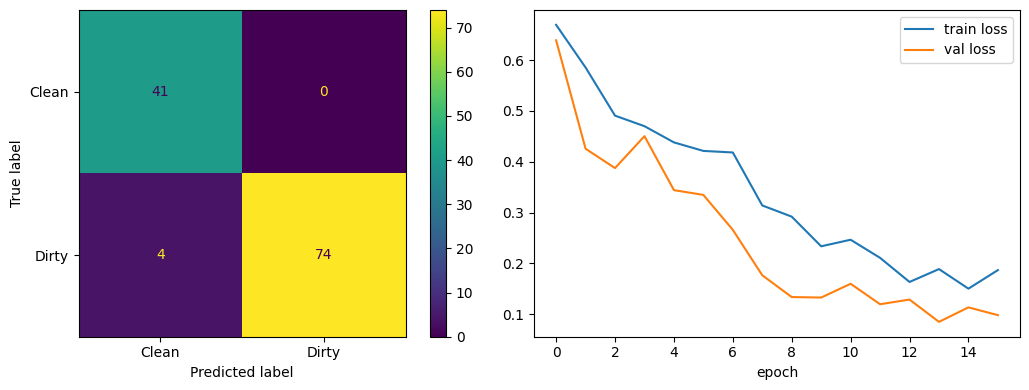

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from solarguard.config import CLASS_NAMES
from solarguard.train import evaluate

load_checkpoint(model, CKPT, device)
val_loss, val_f1, y_true, y_pred = evaluate(model, val_dl, criterion, device)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_NAMES, ax=ax[0])
hist = history1 + history2
ax[1].plot([h["train_loss"] for h in hist], label="train loss")
ax[1].plot([h["val_loss"] for h in hist], label="val loss")
ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

INFO | Loaded test.csv: 108 images


TEST macro-F1: 0.8138
              precision    recall  f1-score   support

       Clean      0.702     0.930     0.800        43
       Dirty      0.941     0.738     0.828        65

    accuracy                          0.815       108
   macro avg      0.821     0.834     0.814       108
weighted avg      0.846     0.815     0.817       108



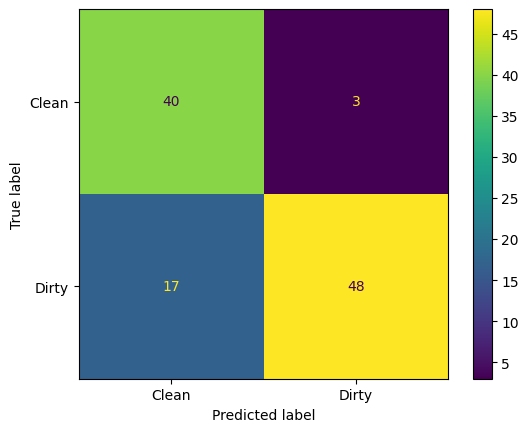

In [13]:
from PIL import Image  # needed by the cell above; run this import first if it errors

test_df = load_split(cfg.split_dir / "test.csv")
test_dl = make_loader(test_df, eval_tf, cfg.batch_size, False, cfg.num_workers, cfg.seed)

load_checkpoint(model, CKPT, device)
_, test_f1, t_true, t_pred = evaluate(model, test_dl, criterion, device)
print("TEST macro-F1:", round(test_f1, 4))
print(classification_report(t_true, t_pred, target_names=CLASS_NAMES, digits=3))
ConfusionMatrixDisplay.from_predictions(t_true, t_pred, display_labels=CLASS_NAMES)
plt.show()

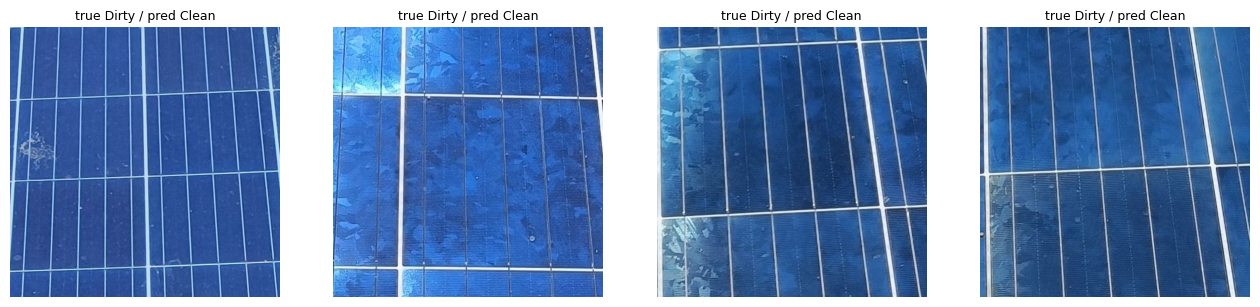

In [14]:
from PIL import Image

errors = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]
fig, axes = plt.subplots(1, max(len(errors), 1), figsize=(4 * max(len(errors), 1), 4), squeeze=False)
for ax, i in zip(axes[0], errors):
    ax.imshow(Image.open(val_df.path.iloc[i]).convert("RGB"))
    ax.set_title(f"true {CLASS_NAMES[y_true[i]]} / pred {CLASS_NAMES[y_pred[i]]}", fontsize=9)
    ax.axis("off")
plt.show()

In [15]:
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()
    out = []
    for x, _ in loader:
        out.append(torch.softmax(model(x.to(device)), dim=1)[:, 1].cpu())
    return torch.cat(out).numpy()

p_dirty = predict_proba(model, test_dl, device)   # test_dl is unshuffled, so order matches test_df
res = test_df.assign(true=t_true, pred=t_pred, p_dirty=p_dirty)
res["wrong"] = res.true != res.pred

print(res.groupby("session").agg(n=("wrong", "size"), wrong=("wrong", "sum")))
print(res[(res.true == 1) & res.wrong].p_dirty.describe().round(3))

          n  wrong
session           
1         2      0
9        57     13
12       26      4
17       21      3
24        2      0
count    17.000
mean      0.071
std       0.112
min       0.000
25%       0.002
50%       0.042
75%       0.074
max       0.469
Name: p_dirty, dtype: float64


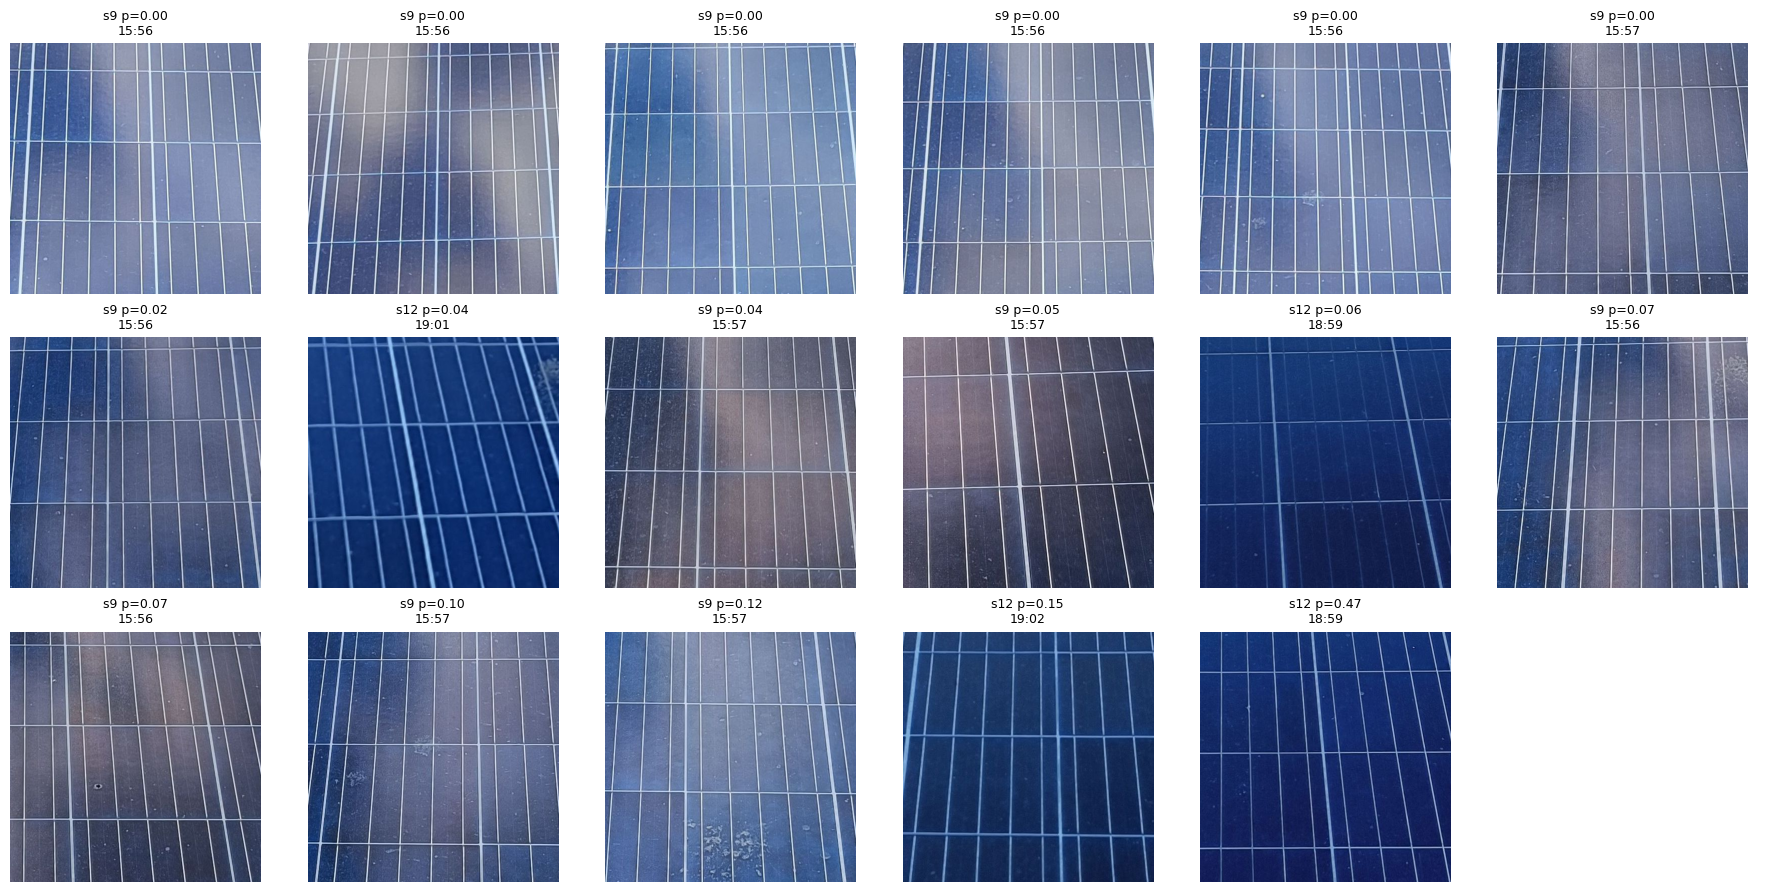

session
1     2024-06-07 07:53:13
9     2024-06-07 15:54:06
12    2024-06-07 18:59:18
17    2024-07-05 18:14:24
24    2024-08-17 19:11:04
Name: timestamp, dtype: object


In [16]:
missed = res[(res.true == 1) & res.wrong].sort_values("p_dirty")
cols = 6
rows = -(-len(missed) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax in axes.flat:
    ax.axis("off")
for ax, (_, r) in zip(axes.flat, missed.iterrows()):
    ax.imshow(Image.open(r.path).convert("RGB"))
    ax.set_title(f"s{r.session} p={r.p_dirty:.2f}\n{str(r.timestamp)[11:16]}", fontsize=9)
plt.tight_layout(); plt.show()

print(res.groupby("session").timestamp.min())

In [17]:
%%writefile -a /content/drive/MyDrive/solarGuard/code/solarguard/train.py


from .model import load_checkpoint, unfreeze_backbone


def train_two_phase(model, train_loader, val_loader, criterion, device, checkpoint_path,
                    head_epochs: int = 6, head_lr: float = 1e-3,
                    tune_epochs: int = 10, tune_lr: float = 1e-4, last_n_blocks: int = 4):
    """Phase 1 trains the new head; phase 2 gently fine-tunes the last blocks."""
    history1, best = fit(model, train_loader, val_loader, criterion,
                         make_optimizer(model, head_lr), device,
                         head_epochs, checkpoint_path)
    load_checkpoint(model, checkpoint_path, device)
    unfreeze_backbone(model, last_n_blocks)
    history2, best = fit(model, train_loader, val_loader, criterion,
                         make_optimizer(model, tune_lr), device,
                         tune_epochs, checkpoint_path, best_f1=best)
    load_checkpoint(model, checkpoint_path, device)
    return history1 + history2, best

Appending to /content/drive/MyDrive/solarGuard/code/solarguard/train.py


In [18]:
import importlib, solarguard.train
importlib.reload(solarguard.train)
from dataclasses import replace
from solarguard.train import train_two_phase

cfg320 = replace(cfg, img_size=320)
tr_tf, ev_tf = build_transforms(cfg320.img_size)
train_dl320 = make_loader(train_df, tr_tf, cfg.batch_size, True, cfg.num_workers, cfg.seed)
val_dl320 = make_loader(val_df, ev_tf, cfg.batch_size, False, cfg.num_workers, cfg.seed)
test_dl320 = make_loader(test_df, ev_tf, cfg.batch_size, False, cfg.num_workers, cfg.seed)

seed_everything(cfg.seed)
model320 = build_model().to(device)
CKPT320 = Path("/content/drive/MyDrive/solarGuard/models/best_320.pt")

hist320, best320 = train_two_phase(model320, train_dl320, val_dl320, criterion, device,
                                   CKPT320, tune_epochs=14)
print("val macro-F1 @320:", round(best320, 4), "| @224 was 0.9636")

_, f1_320, t_true320, t_pred320 = evaluate(model320, test_dl320, criterion, device)
print("TEST macro-F1 @320:", round(f1_320, 4), "| @224 was 0.8138")
print(classification_report(t_true320, t_pred320, target_names=CLASS_NAMES, digits=3))

INFO | epoch  1 | train loss 0.6709 | val loss 0.6322 | val macro-F1 0.5095
INFO |   new best model saved
INFO | epoch  2 | train loss 0.5595 | val loss 0.5309 | val macro-F1 0.7103
INFO |   new best model saved
INFO | epoch  3 | train loss 0.4918 | val loss 0.4738 | val macro-F1 0.7810
INFO |   new best model saved
INFO | epoch  4 | train loss 0.4738 | val loss 0.5151 | val macro-F1 0.7435
INFO | epoch  5 | train loss 0.4393 | val loss 0.4179 | val macro-F1 0.7956
INFO |   new best model saved
INFO | epoch  6 | train loss 0.3952 | val loss 0.4716 | val macro-F1 0.7941
INFO | epoch  1 | train loss 0.4497 | val loss 0.2628 | val macro-F1 0.8596
INFO |   new best model saved
INFO | epoch  2 | train loss 0.2852 | val loss 0.1646 | val macro-F1 0.9033
INFO |   new best model saved
INFO | epoch  3 | train loss 0.2410 | val loss 0.1529 | val macro-F1 0.9237
INFO |   new best model saved
INFO | epoch  4 | train loss 0.2265 | val loss 0.1512 | val macro-F1 0.9319
INFO |   new best model saved


val macro-F1 @320: 0.9723 | @224 was 0.9636
TEST macro-F1 @320: 0.8682 | @224 was 0.8138
              precision    recall  f1-score   support

       Clean      0.784     0.930     0.851        43
       Dirty      0.947     0.831     0.885        65

    accuracy                          0.870       108
   macro avg      0.866     0.881     0.868       108
weighted avg      0.882     0.870     0.872       108



In [20]:
!ls -l /content/drive/MyDrive/solarGuard/code/solarguard/
!grep -n "img_size" /content/drive/MyDrive/solarGuard/code/solarguard/config.py | head -3
!grep -n "pretrained" /content/drive/MyDrive/solarGuard/code/solarguard/model.py | head -3

total 26
-rw------- 1 root root 1691 Oct 10 17:47 config.py
-rw------- 1 root root 4279 Oct 10 17:47 dataprep.py
-rw------- 1 root root 3835 Oct 10 17:47 data.py
-rw------- 1 root root    0 Oct 10 17:47 __init__.py
-rw------- 1 root root 2580 Oct 10 17:48 model.py
-rw------- 1 root root 2964 Oct 10 17:47 predict.py
drwx------ 2 root root 4096 Oct 10 17:50 __pycache__
-rw------- 1 root root 4921 Oct 10 17:49 train.py
33:    img_size: int = 224
42:        if self.session_gap_seconds <= 0 or self.batch_size <= 0 or self.img_size <= 0:
43:            raise ValueError("session_gap_seconds, batch_size and img_size must be positive")
1:"""Model construction: pretrained MobileNetV2 with a new 2-class head."""
15:    """MobileNetV2 pretrained on ImageNet, with its 1000-class head replaced."""


In [21]:
from pathlib import Path
root = Path("/content/drive/MyDrive/solarGuard/code/solarguard")

def patch(file, old, new):
    p = root / file
    s = p.read_text()
    if new in s:
        print(file, "already patched")
        return
    assert s.count(old) == 1, f"{file}: pattern not found exactly once"
    p.write_text(s.replace(old, new))
    print(file, "patched")

patch("config.py", "img_size: int = 224", "img_size: int = 320")
patch("model.py",
      "def build_model(num_classes: int = len(CLASS_NAMES), freeze_backbone: bool = True) -> nn.Module:",
      "def build_model(num_classes: int = len(CLASS_NAMES), freeze_backbone: bool = True,\n"
      "                pretrained: bool = True) -> nn.Module:")
patch("model.py",
      "    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)",
      "    weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None\n"
      "    model = models.mobilenet_v2(weights=weights)")

config.py patched
model.py patched
model.py patched


In [22]:
%%writefile /content/drive/MyDrive/solarGuard/code/solarguard/predict.py
"""Inference for single photos, with input validation for untrusted uploads."""
import io
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import torch
from PIL import Image, UnidentifiedImageError

from .config import CLASS_NAMES
from .data import build_transforms
from .model import build_model, load_checkpoint

logger = logging.getLogger(__name__)

MAX_UPLOAD_BYTES = 10 * 1024 * 1024   # reject files over 10 MB
MAX_PIXELS = 50_000_000               # reject absurdly large images (decompression-bomb guard)
ALLOWED_FORMATS = {"JPEG", "PNG"}


class InvalidImageError(ValueError):
    """Raised when an uploaded file is not an acceptable image."""


@dataclass(frozen=True)
class Prediction:
    label: str
    p_dirty: float


def load_image_safely(data: bytes) -> Image.Image:
    """Validate raw bytes by actually decoding them, then return an RGB image."""
    if not data:
        raise InvalidImageError("Empty file")
    if len(data) > MAX_UPLOAD_BYTES:
        raise InvalidImageError(f"File is larger than {MAX_UPLOAD_BYTES // (1024 * 1024)} MB")
    try:
        with Image.open(io.BytesIO(data)) as probe:
            if probe.format not in ALLOWED_FORMATS:
                raise InvalidImageError(f"Unsupported format: {probe.format}")
            if probe.width * probe.height > MAX_PIXELS:
                raise InvalidImageError("Image dimensions are too large")
            probe.verify()  # checks integrity; the object is unusable afterwards
        with Image.open(io.BytesIO(data)) as img:  # reopen to decode for real
            return img.convert("RGB")
    except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as exc:
        raise InvalidImageError("File is not a valid image") from exc


class Predictor:
    """Loads the trained model once and classifies photos as Clean or Dirty."""

    def __init__(self, checkpoint: Path, img_size: int,
                 threshold: float = 0.5, device: Optional[str] = None):
        if not 0.0 < threshold < 1.0:
            raise ValueError("threshold must be between 0 and 1")
        self.threshold = threshold
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        model = build_model(pretrained=False, freeze_backbone=False)
        self.model = load_checkpoint(model, checkpoint, self.device).to(self.device).eval()
        _, self.transform = build_transforms(img_size)  # same eval preprocessing as validation

    @torch.inference_mode()
    def predict(self, image: Image.Image) -> Prediction:
        batch = self.transform(image).unsqueeze(0).to(self.device)
        p_dirty = torch.softmax(self.model(batch), dim=1)[0, 1].item()
        label = CLASS_NAMES[1] if p_dirty >= self.threshold else CLASS_NAMES[0]
        return Prediction(label=label, p_dirty=p_dirty)

    def predict_bytes(self, data: bytes) -> Prediction:
        return self.predict(load_image_safely(data))

Overwriting /content/drive/MyDrive/solarGuard/code/solarguard/predict.py


In [27]:
!pip -q install gradio
import gradio as gr
from pathlib import Path
from solarguard.config import Config
from solarguard.predict import Predictor, InvalidImageError

cfg = Config()
predictor = Predictor(Path("/content/drive/MyDrive/solarGuard/models/best_320.pt"), cfg.img_size)

def classify(path):
    if not path:
        return "Upload a close-up photo of a solar panel."
    try:
        pred = predictor.predict_bytes(Path(path).read_bytes())
    except InvalidImageError as exc:
        return f"Cannot use this file: {exc}"
    if pred.label == "Dirty":
        return f"DIRTY ({pred.p_dirty:.0%} confidence). Recommendation: clean the panels."
    return f"CLEAN ({1 - pred.p_dirty:.0%} confidence). No cleaning needed."

demo = gr.Interface(
    fn=classify,
    inputs=gr.Image(type="filepath", label="Panel photo (close-up)"),
    outputs="text",
    title="SolarGuard",
    description="Prototype trained on close-up phone photos of rooftop solar panels.",
)
demo.launch(share=True)

INFO | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
INFO | HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"
INFO | HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


INFO | HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64 "HTTP/1.1 200 OK"
INFO | HTTP Request: HEAD https://0ecf372133199db6d5.gradio.live "HTTP/1.1 200 OK"


* Running on public URL: https://0ecf372133199db6d5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
import sys, importlib
from pathlib import Path
sys.path.insert(0, "/content/drive/MyDrive/solarGuard/code")
root = Path("/content/drive/MyDrive/solarGuard/code/solarguard")

def patch(file, old, new):
    p = root / file
    s = p.read_text()
    if new in s:
        print(file, "already patched")
        return
    assert s.count(old) == 1, f"{file}: pattern not found exactly once"
    p.write_text(s.replace(old, new))
    print(file, "patched")

patch("config.py", "img_size: int = 224", "img_size: int = 320")
patch("model.py",
      "def build_model(num_classes: int = len(CLASS_NAMES), freeze_backbone: bool = True) -> nn.Module:",
      "def build_model(num_classes: int = len(CLASS_NAMES), freeze_backbone: bool = True,\n"
      "                pretrained: bool = True) -> nn.Module:")
patch("model.py",
      "    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)",
      "    weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None\n"
      "    model = models.mobilenet_v2(weights=weights)")

import solarguard.config, solarguard.model, solarguard.data, solarguard.predict
for m in (solarguard.config, solarguard.model, solarguard.data, solarguard.predict):
    importlib.reload(m)

from solarguard.config import Config
print("img_size:", Config().img_size)

config.py already patched
model.py already patched
model.py already patched
img_size: 320


In [28]:
!find /content/drive/MyDrive/solarGuard/code -name "__pycache__" -type d -exec rm -rf {} +